# 07 分钟执行偏离代理与 2020 前后检验

> **代理指标警示**：本 Notebook 不是论文 Slippage 的原样复现。论文使用 0.5 秒成交与同时刻最优买卖价构造盘口中间价；当前湖仓只有一分钟 OHLC、成交量与成交额。本项只研究“分钟成交 VWAP 在分钟高低区间中的位置偏离”，结果不得与论文的滑点基点数直接比较。

## 在做什么

对每个固定月份合约的一分钟 bar，用成交额、成交量和权威合约乘数还原分钟 VWAP：

\[
VWAP_{m}=\frac{money_m}{volume_m \times contract\_multiplier}.
\]

用分钟高低价中点 \(mid_m=(high_m+low_m)/2\) 作为缺少盘口时的参考价，定义绝对执行偏离代理：

\[
proxy_m=\left|\frac{VWAP_m-mid_m}{mid_m}\right|\times 10{,}000\ \text{bps}.
\]

先验证 VWAP 与 OHLC、合约乘数的单位是否相容，再按品种形成每周均值、25% 分位、中位数和 75% 分位，最后检验 2020–21 的周均代理是否小于 2016–19。

## 经济意义

真正的滑点衡量订单相对同时刻可成交盘口中间价付出的流动性成本。这里没有买卖方向、最优买卖价和盘口数量，所以分钟高低中点只能提供“成交均价在该分钟价格区间中偏离中心的程度”。

偏离较小可能来自分钟内价格波动较窄、成交更集中于区间中心，或市场冲击较弱；偏离较大也可能只是该分钟趋势强、成交时点集中于区间一侧。它不能单独识别点差、盘口深度、主动买卖方向或因果机制。

## 论文口径与当前实现

论文 Figure 8 定义 \(c_t=|to_t/v_t-p_t^{mid}|\)，按每 0.5 秒样本形成每周分布，并绘制周均值与 25%/75% 分位；Table 5 以 2020-01-01 为断点做 Mann–Whitney U 检验。

当前实现保留“平均成交价相对参考价的绝对偏差、基点化、按周统计、2020 断点”的结构，但存在三项关键差异：

- 参考价由同时刻最优买卖价中点改为一分钟高低价中点；
- 采样频率由 0.5 秒降为一分钟；
- 观察单位是全部有成交的固定月份合约分钟，而非可识别买卖方向的盘口成交。

因此这里只能称为 **minute execution deviation proxy**。单侧检验明确写为 \(H_1\)：2020–21 的周均代理分布低于 2016–19。

## 数据覆盖与适用边界

- 论文日内样本：2016-01-01 至 2021-12-31。
- 当前分钟事实只覆盖 RB、CU、NI、L；M、C 在目标期间没有 `fact_futures_minute` 行。
- 不额外限制日盘：论文滑点段落没有声明只使用日盘，本代理纳入湖仓中全部权威 Session。
- `money` 的权威单位是元，`volume` 是手，`contract_multiplier` 是每手对应标的数量。
- 只有成交量、成交额、OHLC、乘数和最小变动价位都可用且为正/有效的分钟才适用。
- 由于金额与成交量可能有来源舍入，VWAP 落在 \([low-tick,\ high+tick]\) 内视为单位相容；不相容行单独报告并排除，不改写来源值。
- 周内样本是“合约—分钟”，活跃合约会自然贡献更多有成交分钟；统计不是主力合约序列。
- Mann–Whitney U 的样本单位是品种周均值，避免把大量分钟行直接当作相互独立样本；周序列仍可能存在自相关，p 值只作描述性证据。

## 代码步骤

1. 定位项目根目录，导入两张具名权威 Schema。
2. 设置论文样本、目标品种、断点和单位相容阈值。
3. 用 Schema metadata 定位正式 silver 表，检查六品种分钟覆盖。
4. 按品种—年度分区读取合约日历与分钟事实，连接乘数和最小变动价位。
5. 逐分钟复算 VWAP，验证单位相容性，只汇总适用且相容的绝对偏离。
6. 形成每周均值与分位数并绘制 Figure 8 风格代理图。
7. 对周均代理执行“2020–21 更低”的单侧 Mann–Whitney U 检验。
8. 人工复算公式、周统计与检验，并检查图表和覆盖。

## 第 1 步：环境、根目录和权威 Schema

In [1]:
from __future__ import annotations

import pathlib
import sys
from datetime import date

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import display
from scipy.stats import mannwhitneyu

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

PROJECT_ROOT = candidate_root

from config.data_contracts import (  # noqa: E402
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    arrow_to_pandas,
)
from config.settings import settings  # noqa: E402

print(f"project_root: {PROJECT_ROOT}")
print(f"python: {sys.executable}")
print(
    "schema_tables: "
    f"{FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata[b'table_name'].decode('utf-8')}, "
    f"{FUTURES_MINUTE_SCHEMA.metadata[b'table_name'].decode('utf-8')}"
)

project_root: E:\Latitude_Analytics_v2
python: E:\anaconda3\envs\latitude\python.exe
schema_tables: dim_futures_contract_calendar, fact_futures_minute


## 第 2 步：设置论文样本、断点和单位相容参数

In [2]:
PAPER_START_DATE = date(2016, 1, 1)
PAPER_END_DATE = date(2021, 12, 31)
ANALYSIS_START_DATE = PAPER_START_DATE
ANALYSIS_END_DATE = PAPER_END_DATE
BREAK_DATE = date(2020, 1, 1)
UNIT_TOLERANCE_TICKS = 1.0
MIN_UNIT_COMPATIBILITY_RATE = 0.98
SIGNIFICANCE_LEVEL = 0.05

PRODUCTS = [
    {"exchange_code": "XSGE", "underlying_code": "RB", "label": "Steel Rebar"},
    {"exchange_code": "XSGE", "underlying_code": "CU", "label": "Copper"},
    {"exchange_code": "XSGE", "underlying_code": "NI", "label": "Nickel"},
    {"exchange_code": "XDCE", "underlying_code": "L", "label": "Plastic"},
]
UNAVAILABLE_PRODUCTS = [
    {"exchange_code": "XDCE", "underlying_code": "M", "label": "Soybean Meal"},
    {"exchange_code": "XDCE", "underlying_code": "C", "label": "Corn"},
]
ALL_PAPER_PRODUCTS = [*PRODUCTS, *UNAVAILABLE_PRODUCTS]
PRODUCT_KEYS = [
    (product["exchange_code"], product["underlying_code"])
    for product in PRODUCTS
]
PRODUCT_LABEL_BY_KEY = {
    (product["exchange_code"], product["underlying_code"]): product["label"]
    for product in PRODUCTS
}
REGIME_LABELS = ["2016-19", "2020-21"]

if ANALYSIS_START_DATE > ANALYSIS_END_DATE:
    raise ValueError("分析起始日不得晚于结束日")
if not ANALYSIS_START_DATE < BREAK_DATE <= ANALYSIS_END_DATE:
    raise ValueError("2020 断点必须落在分析样本内")
if UNIT_TOLERANCE_TICKS < 0:
    raise ValueError("单位相容容差不得为负")
if not 0 < MIN_UNIT_COMPATIBILITY_RATE <= 1:
    raise ValueError("单位相容率阈值必须位于 (0, 1]")

display(pd.DataFrame(PRODUCTS))
display(pd.DataFrame(UNAVAILABLE_PRODUCTS).assign(reason="目标期间无分钟事实"))
print(f"analysis_dates: {ANALYSIS_START_DATE} to {ANALYSIS_END_DATE}")
print(f"break_date: {BREAK_DATE}")
print(f"unit_tolerance: {UNIT_TOLERANCE_TICKS:.1f} tick")
print(f"minimum_product_compatibility_rate: {MIN_UNIT_COMPATIBILITY_RATE:.1%}")

,exchange_code,underlying_code,label
0,XSGE,RB,Steel Rebar
1,XSGE,CU,Copper
2,XSGE,NI,Nickel
3,XDCE,L,Plastic


,exchange_code,underlying_code,label,reason
0,XDCE,M,Soybean Meal,目标期间无分钟事实
1,XDCE,C,Corn,目标期间无分钟事实


analysis_dates: 2016-01-01 to 2021-12-31
break_date: 2020-01-01
unit_tolerance: 1.0 tick
minimum_product_compatibility_rate: 98.0%


## 第 3 步：定位两张 silver 表并检查分钟覆盖

In [3]:
calendar_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata or {}).items()
}
minute_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_MINUTE_SCHEMA.metadata or {}).items()
}
calendar_path = (
    settings.futures_lake_root / "silver" / calendar_metadata["table_name"]
)
minute_path = settings.futures_lake_root / "silver" / minute_metadata["table_name"]
for table_path in [calendar_path, minute_path]:
    if not table_path.exists():
        raise FileNotFoundError(f"silver 表不存在：{table_path}")

calendar_partition_columns = calendar_metadata["partition_columns"].split(",")
minute_partition_columns = minute_metadata["partition_columns"].split(",")
calendar_partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name).type)
        for column_name in calendar_partition_columns
    ]
)
minute_partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_MINUTE_SCHEMA.field(column_name).type)
        for column_name in minute_partition_columns
    ]
)
calendar_dataset = ds.dataset(
    calendar_path,
    format="parquet",
    partitioning=ds.partitioning(calendar_partitioning_schema, flavor="hive"),
)
minute_dataset = ds.dataset(
    minute_path,
    format="parquet",
    partitioning=ds.partitioning(minute_partitioning_schema, flavor="hive"),
)

calendar_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "contract_multiplier",
    "tick_size",
]
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "high",
    "low",
    "volume",
    "money",
]
calendar_required_schema = pa.schema(
    [FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name) for column_name in calendar_columns]
)
minute_required_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
for required_schema, source_dataset in [
    (calendar_required_schema, calendar_dataset),
    (minute_required_schema, minute_dataset),
]:
    for expected_field in required_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if actual_field.type != expected_field.type:
            raise TypeError(
                f"字段 {expected_field.name} 类型不匹配："
                f"期望 {expected_field.type}，实际 {actual_field.type}"
            )

coverage_records = []
for product in ALL_PAPER_PRODUCTS:
    product_filter = (
        (ds.field("exchange_code") == product["exchange_code"])
        & (ds.field("underlying_code") == product["underlying_code"])
        & (ds.field("year") >= ANALYSIS_START_DATE.year)
        & (ds.field("year") <= ANALYSIS_END_DATE.year)
        & (ds.field("trading_date") >= pa.scalar(ANALYSIS_START_DATE))
        & (ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE))
    )
    coverage_records.append(
        {
            **product,
            "minute_fact_rows": minute_dataset.count_rows(filter=product_filter),
        }
    )

six_product_minute_coverage_df = pd.DataFrame(coverage_records)
six_product_minute_coverage_df["status"] = np.where(
    six_product_minute_coverage_df["minute_fact_rows"] > 0,
    "可计算分钟代理",
    "无分钟事实",
)
display(six_product_minute_coverage_df)
print(f"calendar_path: {calendar_path}")
print(f"minute_path: {minute_path}")

,exchange_code,underlying_code,label,minute_fact_rows,status
0,XSGE,RB,Steel Rebar,6012540,可计算分钟代理
1,XSGE,CU,Copper,7861500,可计算分钟代理
2,XSGE,NI,Nickel,7861500,可计算分钟代理
3,XDCE,L,Plastic,4798620,可计算分钟代理
4,XDCE,M,Soybean Meal,0,无分钟事实
5,XDCE,C,Corn,0,无分钟事实


calendar_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\dim_futures_contract_calendar
minute_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\fact_futures_minute


## 第 4 步：分块复算 VWAP，并验证 OHLC/乘数单位相容性

该步骤只读取目标品种—年度分区。单位相容检验是本研究公式的局部前提，不重新审计或改写上游正式湖：适用行的 VWAP 若超过分钟高低区间一个最小变动价位以上，则单独计数并排除。

In [4]:
analysis_years = list(range(ANALYSIS_START_DATE.year, ANALYSIS_END_DATE.year + 1))
join_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
weekly_absolute_deviation_arrays = {}
chunk_compatibility_records = []
manual_formula_record = None

for product in PRODUCTS:
    exchange_code = product["exchange_code"]
    underlying_code = product["underlying_code"]
    for trading_year in analysis_years:
        chunk_filter = (
            (ds.field("exchange_code") == exchange_code)
            & (ds.field("underlying_code") == underlying_code)
            & (ds.field("year") == trading_year)
            & (ds.field("trading_date") >= pa.scalar(ANALYSIS_START_DATE))
            & (ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE))
        )
        selected_minute_table = minute_dataset.to_table(
            columns=minute_columns,
            filter=chunk_filter,
        )
        if selected_minute_table.num_rows == 0:
            continue
        selected_calendar_table = calendar_dataset.to_table(
            columns=calendar_columns,
            filter=chunk_filter,
        )
        source_minute_chunk_df = arrow_to_pandas(
            selected_minute_table,
            minute_required_schema,
        )
        source_calendar_chunk_df = arrow_to_pandas(
            selected_calendar_table,
            calendar_required_schema,
        )

        source_minute_chunk_df["trading_date"] = pd.to_datetime(
            source_minute_chunk_df["trading_date"]
        )
        source_minute_chunk_df["bar_at"] = pd.to_datetime(
            source_minute_chunk_df["bar_at"]
        )
        source_calendar_chunk_df["trading_date"] = pd.to_datetime(
            source_calendar_chunk_df["trading_date"]
        )
        for numeric_column in ["high", "low", "volume", "money"]:
            source_minute_chunk_df[numeric_column] = pd.to_numeric(
                source_minute_chunk_df[numeric_column],
                errors="coerce",
            ).astype(float)
        for numeric_column in ["contract_multiplier", "tick_size"]:
            source_calendar_chunk_df[numeric_column] = pd.to_numeric(
                source_calendar_chunk_df[numeric_column],
                errors="coerce",
            ).astype(float)

        minute_contract_df = source_minute_chunk_df.merge(
            source_calendar_chunk_df[
                [*join_columns, "contract_multiplier", "tick_size"]
            ],
            on=join_columns,
            how="left",
            validate="many_to_one",
        )

        high_array = minute_contract_df["high"].to_numpy(dtype=float)
        low_array = minute_contract_df["low"].to_numpy(dtype=float)
        volume_array = minute_contract_df["volume"].to_numpy(dtype=float)
        money_array = minute_contract_df["money"].to_numpy(dtype=float)
        multiplier_array = minute_contract_df["contract_multiplier"].to_numpy(dtype=float)
        tick_size_array = minute_contract_df["tick_size"].to_numpy(dtype=float)

        positive_volume_mask = np.isfinite(volume_array) & (volume_array > 0)
        positive_money_mask = np.isfinite(money_array) & (money_array > 0)
        valid_ohlc_mask = (
            np.isfinite(high_array)
            & np.isfinite(low_array)
            & (high_array >= low_array)
            & (low_array > 0)
        )
        valid_contract_terms_mask = (
            np.isfinite(multiplier_array)
            & (multiplier_array > 0)
            & np.isfinite(tick_size_array)
            & (tick_size_array > 0)
        )
        applicable_mask = (
            positive_volume_mask
            & positive_money_mask
            & valid_ohlc_mask
            & valid_contract_terms_mask
        )
        applicable_position = np.flatnonzero(applicable_mask)
        if applicable_position.size == 0:
            raise ValueError(
                f"没有适用的分钟行：{exchange_code}, {underlying_code}, {trading_year}"
            )

        applicable_minute_df = minute_contract_df.iloc[applicable_position].copy()
        applicable_vwap = (
            money_array[applicable_position]
            / (
                volume_array[applicable_position]
                * multiplier_array[applicable_position]
            )
        )
        applicable_midpoint = (
            high_array[applicable_position] + low_array[applicable_position]
        ) / 2
        numerical_tolerance = np.maximum(1e-8, applicable_midpoint * 1e-10)
        price_tolerance = (
            UNIT_TOLERANCE_TICKS * tick_size_array[applicable_position]
            + numerical_tolerance
        )
        compatible_mask = (
            np.isfinite(applicable_vwap)
            & (applicable_vwap > 0)
            & (
                applicable_vwap
                >= low_array[applicable_position] - price_tolerance
            )
            & (
                applicable_vwap
                <= high_array[applicable_position] + price_tolerance
            )
        )
        compatible_position = np.flatnonzero(compatible_mask)
        if compatible_position.size == 0:
            raise ValueError(
                f"没有单位相容的分钟行：{exchange_code}, {underlying_code}, {trading_year}"
            )

        proxy_minute_df = applicable_minute_df.iloc[compatible_position].copy()
        proxy_vwap = applicable_vwap[compatible_position]
        proxy_midpoint = applicable_midpoint[compatible_position]
        proxy_absolute_deviation_bps = (
            np.abs(proxy_vwap - proxy_midpoint) / proxy_midpoint * 10_000
        )
        if not np.isfinite(proxy_absolute_deviation_bps).all():
            raise ValueError("分钟执行偏离代理包含非有限值")
        if (proxy_absolute_deviation_bps < 0).any():
            raise ValueError("绝对执行偏离代理为负")

        proxy_minute_df["absolute_deviation_bps"] = proxy_absolute_deviation_bps
        proxy_minute_df["regime"] = np.where(
            proxy_minute_df["trading_date"] < pd.Timestamp(BREAK_DATE),
            REGIME_LABELS[0],
            REGIME_LABELS[1],
        )
        proxy_minute_df["week_start"] = (
            proxy_minute_df["trading_date"]
            - pd.to_timedelta(proxy_minute_df["trading_date"].dt.weekday, unit="D")
        ).dt.normalize()
        post_partial_week_mask = (
            (proxy_minute_df["regime"] == REGIME_LABELS[1])
            & (proxy_minute_df["week_start"] < pd.Timestamp(BREAK_DATE))
        )
        proxy_minute_df.loc[post_partial_week_mask, "week_start"] = pd.Timestamp(
            BREAK_DATE
        )

        for group_key, group_df in proxy_minute_df.groupby(
            ["exchange_code", "underlying_code", "regime", "week_start"],
            observed=True,
            sort=False,
        ):
            weekly_absolute_deviation_arrays.setdefault(group_key, []).append(
                group_df["absolute_deviation_bps"].to_numpy(dtype=float)
            )

        if manual_formula_record is None:
            manual_position = int(compatible_position[0])
            manual_formula_record = {
                "money": float(applicable_minute_df.iloc[manual_position]["money"]),
                "volume": float(applicable_minute_df.iloc[manual_position]["volume"]),
                "contract_multiplier": float(
                    applicable_minute_df.iloc[manual_position]["contract_multiplier"]
                ),
                "high": float(applicable_minute_df.iloc[manual_position]["high"]),
                "low": float(applicable_minute_df.iloc[manual_position]["low"]),
                "tick_size": float(
                    applicable_minute_df.iloc[manual_position]["tick_size"]
                ),
                "reported_vwap": float(proxy_vwap[0]),
                "reported_absolute_deviation_bps": float(
                    proxy_absolute_deviation_bps[0]
                ),
            }

        chunk_compatibility_records.append(
            {
                "exchange_code": exchange_code,
                "underlying_code": underlying_code,
                "trading_year": trading_year,
                "source_rows": len(minute_contract_df),
                "positive_volume_rows": int(positive_volume_mask.sum()),
                "positive_money_rows": int(positive_money_mask.sum()),
                "valid_ohlc_rows": int(valid_ohlc_mask.sum()),
                "valid_contract_term_rows": int(valid_contract_terms_mask.sum()),
                "applicable_rows": int(applicable_position.size),
                "compatible_rows": int(compatible_position.size),
                "incompatible_rows": int(applicable_position.size - compatible_position.size),
                "unit_compatibility_rate": float(
                    compatible_position.size / applicable_position.size
                ),
                "contracts": int(proxy_minute_df["contract_code"].nunique()),
                "first_trading_date": proxy_minute_df["trading_date"].min(),
                "last_trading_date": proxy_minute_df["trading_date"].max(),
            }
        )

chunk_compatibility_df = pd.DataFrame(chunk_compatibility_records)
product_compatibility_summary_df = (
    chunk_compatibility_df.groupby(
        ["exchange_code", "underlying_code"],
        observed=True,
        as_index=False,
    )
    .agg(
        source_rows=("source_rows", "sum"),
        applicable_rows=("applicable_rows", "sum"),
        compatible_rows=("compatible_rows", "sum"),
        incompatible_rows=("incompatible_rows", "sum"),
        contracts=("contracts", "max"),
        first_trading_date=("first_trading_date", "min"),
        last_trading_date=("last_trading_date", "max"),
    )
)
product_compatibility_summary_df["unit_compatibility_rate"] = (
    product_compatibility_summary_df["compatible_rows"]
    / product_compatibility_summary_df["applicable_rows"]
)
product_compatibility_summary_df["label"] = product_compatibility_summary_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[
        (row["exchange_code"], row["underlying_code"])
    ],
    axis=1,
)

display(chunk_compatibility_df)
display(product_compatibility_summary_df)
print(f"source_minute_rows_read: {chunk_compatibility_df['source_rows'].sum():,}")
print(f"applicable_minute_rows: {chunk_compatibility_df['applicable_rows'].sum():,}")
print(f"compatible_proxy_rows: {chunk_compatibility_df['compatible_rows'].sum():,}")
print(
    "incompatible_applicable_rows_excluded: "
    f"{chunk_compatibility_df['incompatible_rows'].sum():,}"
)

,exchange_code,underlying_code,trading_year,source_rows,positive_volume_rows,positive_money_rows,valid_ohlc_rows,valid_contract_term_rows,applicable_rows,compatible_rows,incompatible_rows,unit_compatibility_rate,contracts,first_trading_date,last_trading_date
0,XSGE,RB,2016,1109520,447704,447704,1109520,1109520,447704,447387,317,0.999292,24,2016-01-04,2016-12-30
1,XSGE,RB,2017,1001520,348535,348535,1001520,1001520,348535,348303,232,0.999334,24,2017-01-03,2017-12-29
2,XSGE,RB,2018,995940,341628,341628,995940,995940,341628,341432,196,0.999426,24,2018-01-02,2018-12-28
3,XSGE,RB,2019,1000080,349455,349455,1000080,1000080,349455,349178,277,0.999207,24,2019-01-02,2019-12-31
4,XSGE,RB,2020,909540,397001,397001,909540,909540,397001,396835,166,0.999582,24,2020-01-02,2020-12-31
5,XSGE,RB,2021,995940,580285,580285,995940,995940,580285,579826,459,0.999209,24,2021-01-04,2021-12-31
6,XSGE,CU,2016,1341360,590141,590141,1341360,1341360,590141,589701,440,0.999254,24,2016-01-04,2016-12-30
7,XSGE,CU,2017,1344240,628748,628748,1344240,1344240,628748,628310,438,0.999303,24,2017-01-03,2017-12-29
8,XSGE,CU,2018,1335780,670007,670007,1335780,1335780,670007,669802,205,0.999694,24,2018-01-02,2018-12-28
9,XSGE,CU,2019,1341360,548751,548751,1341360,1341360,548751,548651,100,0.999818,24,2019-01-02,2019-12-31


,exchange_code,underlying_code,source_rows,applicable_rows,compatible_rows,incompatible_rows,contracts,first_trading_date,last_trading_date,unit_compatibility_rate,label
0,XDCE,L,4798620,1388968,1383240,5728,24,2016-01-04,2021-12-31,0.995876,Plastic
1,XSGE,CU,7861500,3582289,3580586,1703,24,2016-01-04,2021-12-31,0.999525,Copper
2,XSGE,NI,7861500,2611596,2609147,2449,24,2016-01-04,2021-12-31,0.999062,Nickel
3,XSGE,RB,6012540,2464608,2462961,1647,24,2016-01-04,2021-12-31,0.999332,Steel Rebar


source_minute_rows_read: 26,534,160
applicable_minute_rows: 10,047,461
compatible_proxy_rows: 10,035,934
incompatible_applicable_rows_excluded: 11,527


## 第 5 步：形成每周分布与 2016–19 / 2020–21 汇总

周从星期一开始。断点所在周被拆成 2019-12-30 至 2019-12-31 和 2020-01-01 起两个部分，以免把断点后的分钟归入前期。下表中的期间统计是相应周度曲线的跨周平均。

In [5]:
weekly_summary_records = []
for group_key, deviation_array_parts in weekly_absolute_deviation_arrays.items():
    weekly_values = np.concatenate(deviation_array_parts)
    weekly_summary_records.append(
        {
            "exchange_code": group_key[0],
            "underlying_code": group_key[1],
            "regime": group_key[2],
            "week_start": pd.Timestamp(group_key[3]),
            "minute_observations": int(weekly_values.size),
            "weekly_mean_bps": float(weekly_values.mean()),
            "weekly_q25_bps": float(np.quantile(weekly_values, 0.25)),
            "weekly_median_bps": float(np.quantile(weekly_values, 0.50)),
            "weekly_q75_bps": float(np.quantile(weekly_values, 0.75)),
        }
    )

weekly_proxy_summary_df = (
    pd.DataFrame(weekly_summary_records)
    .sort_values(["exchange_code", "underlying_code", "week_start", "regime"])
    .reset_index(drop=True)
)
weekly_proxy_summary_df["label"] = weekly_proxy_summary_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[
        (row["exchange_code"], row["underlying_code"])
    ],
    axis=1,
)

regime_proxy_summary_df = (
    weekly_proxy_summary_df.groupby(
        ["exchange_code", "underlying_code", "label", "regime"],
        observed=True,
        as_index=False,
    )
    .agg(
        weeks=("week_start", "size"),
        minute_observations=("minute_observations", "sum"),
        first_week=("week_start", "min"),
        last_week=("week_start", "max"),
        mean_bps=("weekly_mean_bps", "mean"),
        q25_bps=("weekly_q25_bps", "mean"),
        median_bps=("weekly_median_bps", "mean"),
        q75_bps=("weekly_q75_bps", "mean"),
    )
)

regime_proxy_display_df = regime_proxy_summary_df.copy()
regime_proxy_numeric_columns = [
    "mean_bps", "q25_bps", "median_bps", "q75_bps"
]
regime_proxy_display_df[regime_proxy_numeric_columns] = (
    regime_proxy_display_df[regime_proxy_numeric_columns].round(4)
)
display(regime_proxy_display_df)
print(f"weekly_product_rows: {len(weekly_proxy_summary_df):,}")
print(
    "weekly_minute_observations: "
    f"{weekly_proxy_summary_df['minute_observations'].sum():,}"
)

,exchange_code,underlying_code,label,regime,weeks,minute_observations,first_week,last_week,mean_bps,q25_bps,median_bps,q75_bps
0,XDCE,L,Plastic,2016-19,204,610050,2016-01-04,2019-12-30,1.2798,0.1329,0.9316,2.0775
1,XDCE,L,Plastic,2020-21,104,773190,2020-01-01,2021-12-27,1.2355,0.0292,0.5851,2.1008
2,XSGE,CU,Copper,2016-19,204,2436464,2016-01-04,2019-12-30,0.5130,0.0005,0.2904,0.7774
3,XSGE,CU,Copper,2020-21,104,1144122,2020-01-01,2021-12-27,0.5348,0.0150,0.3375,0.7673
4,XSGE,NI,Nickel,2016-19,204,1546696,2016-01-04,2019-12-30,0.7432,0.0821,0.4120,0.9391
5,XSGE,NI,Nickel,2020-21,104,1062451,2020-01-01,2021-12-27,0.7395,0.1055,0.4377,0.9826
6,XSGE,RB,Steel Rebar,2016-19,204,1486300,2016-01-04,2019-12-30,1.0090,0.0279,0.5645,1.3711
7,XSGE,RB,Steel Rebar,2020-21,104,976661,2020-01-01,2021-12-27,0.9265,0.1006,0.5770,1.2767


weekly_product_rows: 1,232
weekly_minute_observations: 10,035,934


## 第 6 步：绘制 Figure 8 风格的分钟代理图

蓝线是每周合约—分钟绝对偏离均值，红线和橙线分别是周内 25% 与 75% 分位，浅红色带只是帮助识别分位区间；虚线是 2020-01-01。纵轴是本 Notebook 的分钟代理基点，不是原论文滑点。

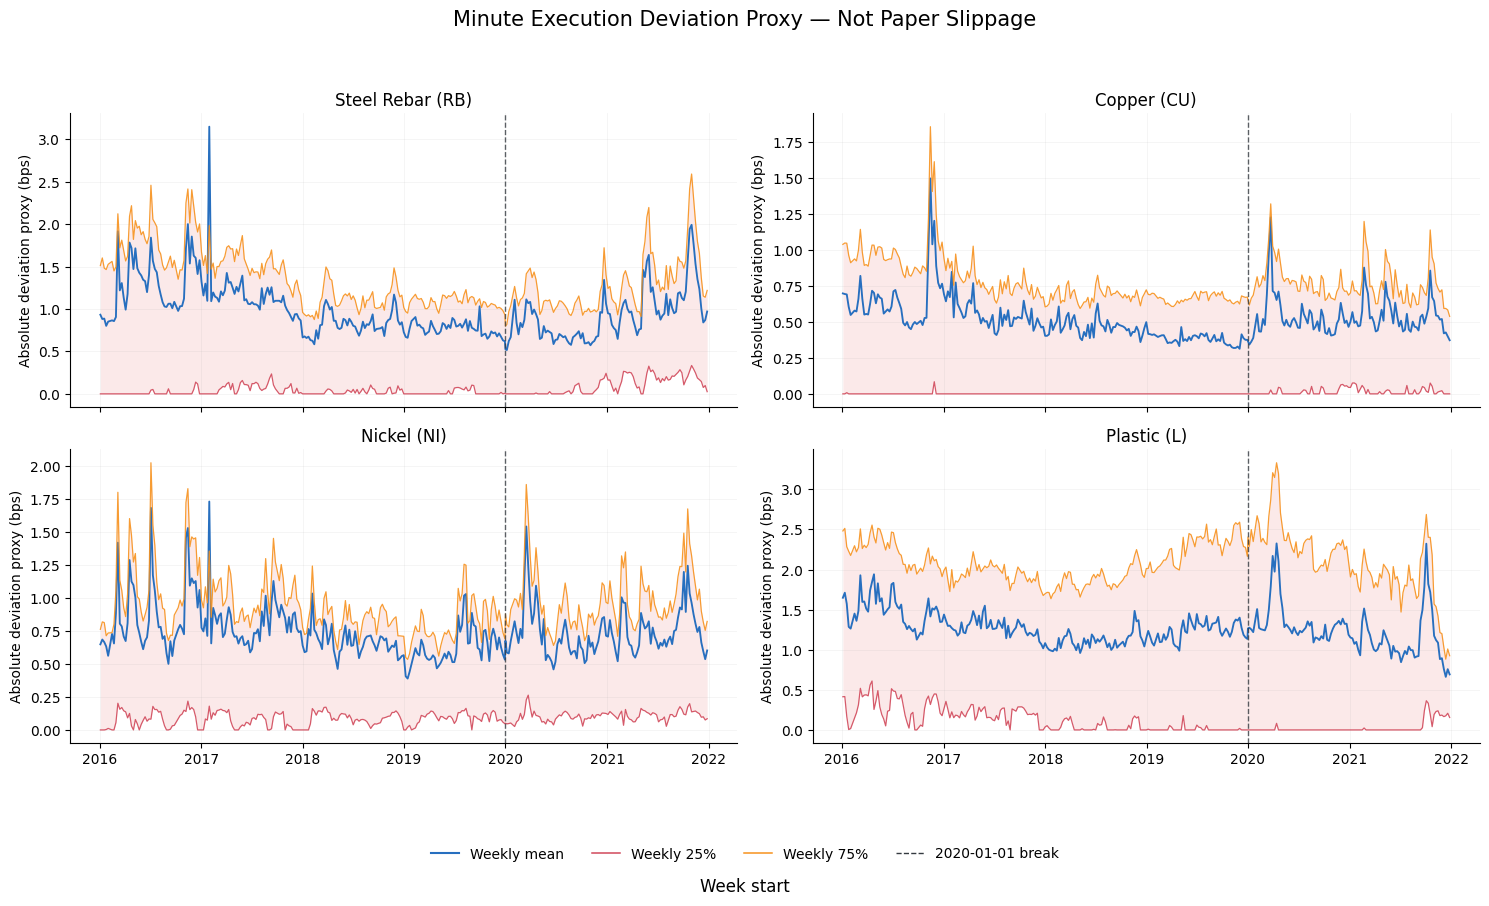

In [6]:
figure8_proxy, axes8_proxy = plt.subplots(
    2,
    2,
    figsize=(15, 9),
    sharex=True,
)
panel_metric_line_count = {}
for axis, product in zip(axes8_proxy.flat, PRODUCTS, strict=True):
    product_weekly_df = weekly_proxy_summary_df.loc[
        (weekly_proxy_summary_df["exchange_code"] == product["exchange_code"])
        & (
            weekly_proxy_summary_df["underlying_code"]
            == product["underlying_code"]
        )
    ].sort_values("week_start")
    if product_weekly_df.empty:
        raise AssertionError(
            f"代理图面板为空：{product['exchange_code']}, {product['underlying_code']}"
        )

    x_values = product_weekly_df["week_start"]
    q25_values = product_weekly_df["weekly_q25_bps"].to_numpy(dtype=float)
    q75_values = product_weekly_df["weekly_q75_bps"].to_numpy(dtype=float)
    axis.fill_between(
        x_values,
        q25_values,
        q75_values,
        color="#E45756",
        alpha=0.13,
        linewidth=0,
    )
    axis.plot(
        x_values,
        product_weekly_df["weekly_mean_bps"],
        color="#276FBF",
        linewidth=1.35,
        label="Weekly mean",
    )
    axis.plot(
        x_values,
        q25_values,
        color="#D1495B",
        linewidth=0.9,
        alpha=0.9,
        label="Weekly 25%",
    )
    axis.plot(
        x_values,
        q75_values,
        color="#F7921E",
        linewidth=0.9,
        alpha=0.9,
        label="Weekly 75%",
    )
    axis.axvline(
        pd.Timestamp(BREAK_DATE),
        color="#343A40",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
    )
    panel_metric_line_count[
        (product["exchange_code"], product["underlying_code"])
    ] = 3
    axis.set_title(f"{product['label']} ({product['underlying_code']})")
    axis.set_ylabel("Absolute deviation proxy (bps)")
    axis.grid(alpha=0.18, linewidth=0.5)
    axis.spines[["top", "right"]].set_visible(False)

legend_handles = [
    Line2D([0], [0], color="#276FBF", linewidth=1.5, label="Weekly mean"),
    Line2D([0], [0], color="#D1495B", linewidth=1.1, label="Weekly 25%"),
    Line2D([0], [0], color="#F7921E", linewidth=1.1, label="Weekly 75%"),
    Line2D(
        [0],
        [0],
        color="#343A40",
        linestyle="--",
        linewidth=1.0,
        label="2020-01-01 break",
    ),
]
figure8_proxy.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.035),
)
figure8_proxy.suptitle(
    "Minute Execution Deviation Proxy — Not Paper Slippage",
    fontsize=15,
    y=0.995,
)
figure8_proxy.supxlabel("Week start", y=0.01)
figure8_proxy.tight_layout(rect=(0, 0.10, 1, 0.96))
plt.show()

## 第 7 步：2020 前后的单侧 Mann–Whitney U 检验

每个品种以“周均绝对偏离代理”为样本。调用顺序是 `x=2020–21`、`y=2016–19`，`alternative="less"`，因此备择假设是后期分布更低。`probability_post_below_pre` 由 U 统计量换算，接近 1 表示随机抽取一个后期周均值时，它低于随机前期周均值的概率更高（平局按一半计）。

In [7]:
mann_whitney_records = []
for product in PRODUCTS:
    product_weekly_df = weekly_proxy_summary_df.loc[
        (weekly_proxy_summary_df["exchange_code"] == product["exchange_code"])
        & (
            weekly_proxy_summary_df["underlying_code"]
            == product["underlying_code"]
        )
    ]
    pre_values = product_weekly_df.loc[
        product_weekly_df["regime"] == REGIME_LABELS[0],
        "weekly_mean_bps",
    ].to_numpy(dtype=float)
    post_values = product_weekly_df.loc[
        product_weekly_df["regime"] == REGIME_LABELS[1],
        "weekly_mean_bps",
    ].to_numpy(dtype=float)
    if pre_values.size == 0 or post_values.size == 0:
        raise ValueError(
            f"断点前后样本不完整：{product['exchange_code']}, {product['underlying_code']}"
        )

    test_result = mannwhitneyu(
        post_values,
        pre_values,
        alternative="less",
        method="auto",
    )
    pair_count = post_values.size * pre_values.size
    mann_whitney_records.append(
        {
            "exchange_code": product["exchange_code"],
            "underlying_code": product["underlying_code"],
            "label": product["label"],
            "pre_weeks": int(pre_values.size),
            "post_weeks": int(post_values.size),
            "pre_median_weekly_mean_bps": float(np.median(pre_values)),
            "post_median_weekly_mean_bps": float(np.median(post_values)),
            "post_minus_pre_median_bps": float(
                np.median(post_values) - np.median(pre_values)
            ),
            "u_statistic": float(test_result.statistic),
            "p_value_one_sided_post_less": float(test_result.pvalue),
            "probability_post_below_pre": float(
                1 - test_result.statistic / pair_count
            ),
        }
    )

mann_whitney_result_df = pd.DataFrame(mann_whitney_records)
mann_whitney_result_df["conclusion_at_5pct"] = np.where(
    mann_whitney_result_df["p_value_one_sided_post_less"] < SIGNIFICANCE_LEVEL,
    "后期周均代理显著更低",
    "未发现后期周均代理显著更低",
)
display(mann_whitney_result_df.round(6))

,exchange_code,underlying_code,label,pre_weeks,post_weeks,pre_median_weekly_mean_bps,post_median_weekly_mean_bps,post_minus_pre_median_bps,u_statistic,p_value_one_sided_post_less,probability_post_below_pre,conclusion_at_5pct
0,XSGE,RB,Steel Rebar,204,104,0.905306,0.872844,-0.032461,8669.0,0.004362,0.591393,后期周均代理显著更低
1,XSGE,CU,Copper,204,104,0.479006,0.507226,0.028220,12248.0,0.986774,0.422700,未发现后期周均代理显著更低
2,XSGE,NI,Nickel,204,104,0.707485,0.694289,-0.013196,10621.0,0.507286,0.499387,未发现后期周均代理显著更低
3,XDCE,L,Plastic,204,104,1.255854,1.210200,-0.045654,8666.0,0.004310,0.591535,后期周均代理显著更低


## 验证

In [8]:
available_product_keys = set(
    product_compatibility_summary_df[
        ["exchange_code", "underlying_code"]
    ].itertuples(index=False, name=None)
)
if available_product_keys != set(PRODUCT_KEYS):
    raise AssertionError("四个可用分钟品种覆盖不完整")

unavailable_coverage_df = six_product_minute_coverage_df.loc[
    six_product_minute_coverage_df["underlying_code"].isin(["M", "C"])
]
if not (unavailable_coverage_df["minute_fact_rows"] == 0).all():
    raise AssertionError("M 或 C 已有分钟事实，应重新评估代理覆盖")

if (
    product_compatibility_summary_df["unit_compatibility_rate"]
    < MIN_UNIT_COMPATIBILITY_RATE
).any():
    raise AssertionError("至少一个品种的 VWAP/OHLC 单位相容率低于设定阈值")
if (product_compatibility_summary_df["compatible_rows"] <= 0).any():
    raise AssertionError("至少一个品种没有单位相容的代理行")

weekly_value_columns = [
    "weekly_mean_bps",
    "weekly_q25_bps",
    "weekly_median_bps",
    "weekly_q75_bps",
]
weekly_value_array = weekly_proxy_summary_df[weekly_value_columns].to_numpy(dtype=float)
if not np.isfinite(weekly_value_array).all():
    raise AssertionError("周度代理统计包含非有限值")
if (weekly_value_array < 0).any():
    raise AssertionError("周度绝对偏离统计为负")
if not (
    (
        weekly_proxy_summary_df["weekly_q25_bps"]
        <= weekly_proxy_summary_df["weekly_median_bps"]
    )
    & (
        weekly_proxy_summary_df["weekly_median_bps"]
        <= weekly_proxy_summary_df["weekly_q75_bps"]
    )
).all():
    raise AssertionError("周度分位数顺序不正确")

if manual_formula_record is None:
    raise AssertionError("没有保留公式人工复算样本")
manual_vwap = (
    manual_formula_record["money"]
    / (
        manual_formula_record["volume"]
        * manual_formula_record["contract_multiplier"]
    )
)
manual_midpoint = (
    manual_formula_record["high"] + manual_formula_record["low"]
) / 2
manual_absolute_deviation_bps = (
    abs(manual_vwap - manual_midpoint) / manual_midpoint * 10_000
)
if not np.isclose(
    manual_vwap,
    manual_formula_record["reported_vwap"],
    rtol=1e-12,
    atol=1e-12,
):
    raise AssertionError("分钟 VWAP 人工复算不一致")
if not np.isclose(
    manual_absolute_deviation_bps,
    manual_formula_record["reported_absolute_deviation_bps"],
    rtol=1e-12,
    atol=1e-12,
):
    raise AssertionError("分钟绝对偏离人工复算不一致")

manual_week_row = weekly_proxy_summary_df.iloc[0]
manual_week_key = (
    manual_week_row["exchange_code"],
    manual_week_row["underlying_code"],
    manual_week_row["regime"],
    manual_week_row["week_start"],
)
manual_week_values = np.concatenate(
    weekly_absolute_deviation_arrays[manual_week_key]
)
manual_week_statistics = np.array(
    [
        manual_week_values.mean(),
        np.quantile(manual_week_values, 0.25),
        np.quantile(manual_week_values, 0.50),
        np.quantile(manual_week_values, 0.75),
    ],
    dtype=float,
)
reported_week_statistics = manual_week_row[weekly_value_columns].to_numpy(dtype=float)
if manual_week_row["minute_observations"] != manual_week_values.size:
    raise AssertionError("周内分钟样本数复算不一致")
if not np.allclose(
    manual_week_statistics,
    reported_week_statistics,
    rtol=1e-12,
    atol=1e-12,
):
    raise AssertionError("周均值或分位数人工复算不一致")

manual_product = PRODUCTS[0]
manual_product_weekly_df = weekly_proxy_summary_df.loc[
    (
        weekly_proxy_summary_df["exchange_code"]
        == manual_product["exchange_code"]
    )
    & (
        weekly_proxy_summary_df["underlying_code"]
        == manual_product["underlying_code"]
    )
]
manual_pre_values = manual_product_weekly_df.loc[
    manual_product_weekly_df["regime"] == REGIME_LABELS[0],
    "weekly_mean_bps",
].to_numpy(dtype=float)
manual_post_values = manual_product_weekly_df.loc[
    manual_product_weekly_df["regime"] == REGIME_LABELS[1],
    "weekly_mean_bps",
].to_numpy(dtype=float)
manual_test_result = mannwhitneyu(
    manual_post_values,
    manual_pre_values,
    alternative="less",
    method="auto",
)
reported_test_row = mann_whitney_result_df.loc[
    (
        mann_whitney_result_df["exchange_code"]
        == manual_product["exchange_code"]
    )
    & (
        mann_whitney_result_df["underlying_code"]
        == manual_product["underlying_code"]
    )
].iloc[0]
if not np.isclose(
    manual_test_result.statistic,
    reported_test_row["u_statistic"],
    rtol=0,
    atol=0,
):
    raise AssertionError("Mann–Whitney U 统计量人工复算不一致")
if not np.isclose(
    manual_test_result.pvalue,
    reported_test_row["p_value_one_sided_post_less"],
    rtol=1e-12,
    atol=1e-15,
):
    raise AssertionError("Mann–Whitney p 值人工复算不一致")

if len(axes8_proxy.flat) != len(PRODUCTS):
    raise AssertionError("代理图面板数不正确")
if set(panel_metric_line_count.values()) != {3}:
    raise AssertionError("代理图至少一个面板缺少均值或分位数曲线")
if any(len(axis.lines) != 4 for axis in axes8_proxy.flat):
    raise AssertionError("代理图至少一个面板缺少三条指标线或断点线")
if any(len(axis.collections) < 1 for axis in axes8_proxy.flat):
    raise AssertionError("代理图至少一个面板缺少 25%–75% 分位带")

expected_test_products = set(PRODUCT_KEYS)
actual_test_products = set(
    mann_whitney_result_df[
        ["exchange_code", "underlying_code"]
    ].itertuples(index=False, name=None)
)
if actual_test_products != expected_test_products:
    raise AssertionError("单侧检验没有覆盖全部四个可用品种")
test_probability_array = mann_whitney_result_df[
    ["p_value_one_sided_post_less", "probability_post_below_pre"]
].to_numpy(dtype=float)
if ((test_probability_array < 0) | (test_probability_array > 1)).any():
    raise AssertionError("p 值或概率解释不在 [0, 1]")

print(
    f"validation_ok: {len(available_product_keys)} products, "
    f"{len(weekly_proxy_summary_df):,} product-weeks, "
    f"{int(weekly_proxy_summary_df['minute_observations'].sum()):,} compatible contract-minutes, "
    f"minimum compatibility rate "
    f"{product_compatibility_summary_df['unit_compatibility_rate'].min():.2%}"
)

validation_ok: 4 products, 1,232 product-weeks, 10,035,934 compatible contract-minutes, minimum compatibility rate 99.59%


## 如何解释结果

先看单位相容表：它回答“成交额/成交量/乘数能否还原到与 OHLC 同一报价单位”。高相容率支持继续计算，但不证明参考价等于盘口中间价；被排除的不相容行是来源舍入、合约条款映射或字段语义差异的诊断对象，不能静默修写。

再看代理图和期间表：蓝线下降只表示有成交的合约分钟中，VWAP 相对分钟区间中心的绝对偏离下降。它可能与分钟内波动、成交时点、合约活跃度结构共同变化，不能直接解释为交易成本下降。

最后看单侧检验：只有 `p_value_one_sided_post_less < 0.05` 时，才说“周均分钟代理在 2020–21 显著更低”。即使显著，也不等于论文基于 Level 1 盘口的 Slippage 显著下降，更不能据此识别监管、算法交易或流动性供给的因果作用。M、C 仍需补齐分钟事实；六品种的原论文滑点与相应检验仍需 0.5 秒最优买卖价量。